In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

https://math.stackexchange.com/questions/5125314/what-type-of-bifurcation-occurs-at-lambda-0-for-the-nonlinear-dynamical-sys?noredirect=1#comment11050269_5125314

In [2]:
def model(t, y, k):
    return np.array([
        y[0] * (y[0] ** 2 - 1.) * (k - y[0] ** 2),
        np.ones(shape=y[1].shape),
    ])

In [3]:
k = 0.9

In [4]:
t = np.linspace(0, 12.5, 200)

In [5]:
solution = integrate.solve_ivp(model, [t[0], t[-1]], y0=[0.51, -6.], t_eval=t, method="LSODA", args=(k,))

In [6]:
solution

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  6.281e-02 ...  1.244e+01  1.250e+01]
        y: [[ 5.100e-01  4.946e-01 ...  9.919e-06  9.370e-06]
            [-6.000e+00 -5.937e+00 ...  6.437e+00  6.500e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 71
     njev: 0
      nlu: 0

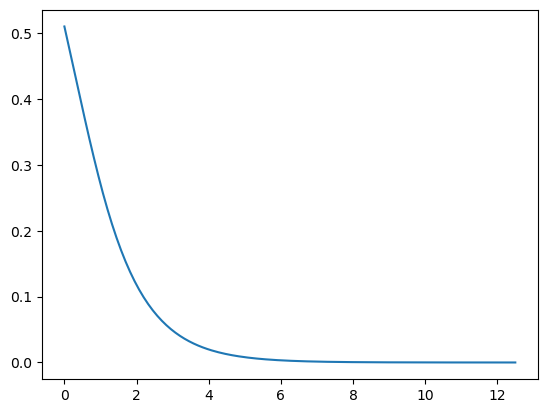

In [7]:
fig, axe = plt.subplots()
axe.plot(t, solution.y[0])

In [8]:
rho = np.linspace(-0.25, 1.5, 200)
theta = np.linspace(-3. * np.pi, 3. * np.pi, 200)

In [9]:
R, T = np.meshgrid(rho, theta)

In [10]:
U, V = model(None, [R, T], k)

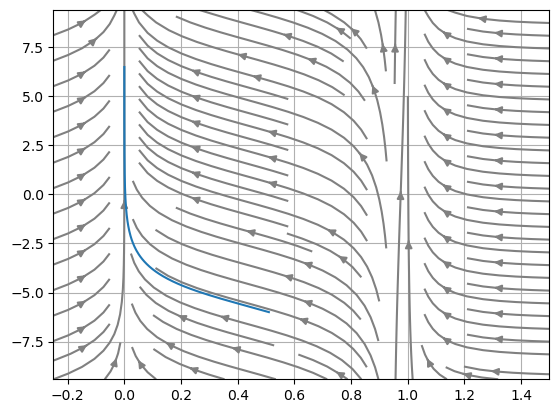

In [11]:
fig, axe = plt.subplots()
axe.streamplot(R, T, U, V, color="gray")
axe.plot(*solution.y)
axe.grid()

In [12]:
rho, theta = solution.y

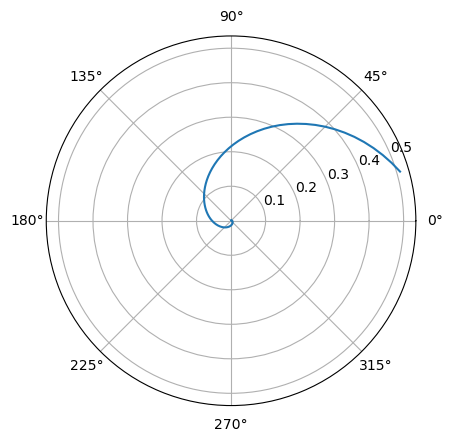

In [13]:
fig, axe = plt.subplots(subplot_kw={'projection': 'polar'})
axe.plot(*np.flip(solution.y))

In [14]:
def func(x, k):
    return x * (x ** 2 - 1.) * (k - x ** 2)

In [15]:
def diagram(r, x=0.1, n=1200, m=200):
    if not isinstance(x, np.ndarray):
        x = np.full(r.size, x)
    xs = []
    for i in range(n):
        if i >= n - m:
            xs.append(x)
        x = func(x, r)
    return np.array(xs).T

In [16]:
ktest = np.linspace(-1., 1., 20)
xtest = diagram(ktest, n=30, m=30)

In [17]:
rlin = np.linspace(-2, 2, 5000)
xlin = np.linspace(-1, 1, 10)
clin = np.linspace(0., 1., xlin.size)
colors = plt.get_cmap("cool")(clin)

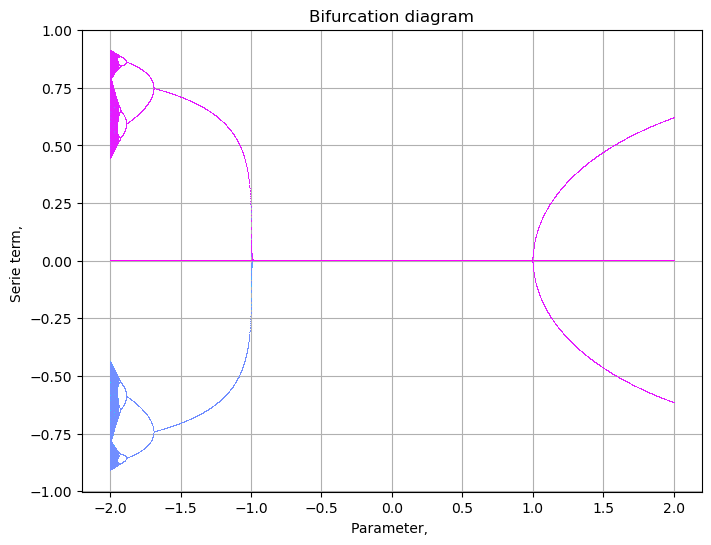

In [18]:
fig, axe = plt.subplots(figsize=(8, 6))
for x0, color in zip(xlin, colors):
    x = diagram(rlin, x=x0, n=600, m=100)
    axe.plot(rlin, x, ',', color=color)
axe.set_title("Bifurcation diagram")
axe.set_xlabel("Parameter, ")
axe.set_ylabel("Serie term, ")
axe.grid()